# 

# 

In [ ]:
import pandas as pd

df = pd.read_csv("train.csv", sep=";")
df.head()

In [ ]:
# Separación de variables independientes (X) y variable dependiente (y)

# X contiene las características de las viviendas (variables explicativas)
X = df.drop("SalePrice", axis=1)

# y contiene el valor real del precio de venta (variable objetivo)
y = df["SalePrice"]

# Visualización de las primeras filas para verificar la correcta separación
print("Variables independientes (X):")
display(X.head())

print("Variable dependiente (y):")
display(y.head().to_frame())


In [184]:
import numpy as np

# PREPARACIÓN DE LOS DATOS PARA EL MODELO NUMÉRICO

# Se elimina la columna Id porque solo identifica registros y no aporta información matemática al modelo

X_modelo = X.drop("Id", axis=1)

# Conversión de los datos a arreglos numéricos (forma matricial)
matriz_A = X_modelo.values
vector_b = y.values



# APLICACIÓN DEL MÉTODO DE MÍNIMOS CUADRADOS (Construcción y resolución de la ecuación normal)

# Se calcula la transpuesta de la matriz A
matriz_AT = matriz_A.T

# Se construyen los términos de la ecuación normal:
# (AᵀA)x = Aᵀb

matriz_ATA = np.dot(matriz_AT, matriz_A)
vector_ATb = np.dot(matriz_AT, vector_b)

# Se resuelve el sistema lineal para obtener los coeficientes del modelo
coeficientes_modelo = np.linalg.solve(matriz_ATA, vector_ATb)


# PREDICCIÓN DE LOS PRECIOS DE LAS VIVIENDAS

# Se calculan los valores estimados utilizando el modelo obtenido
precios_estimados = np.dot(matriz_A, coeficientes_modelo)


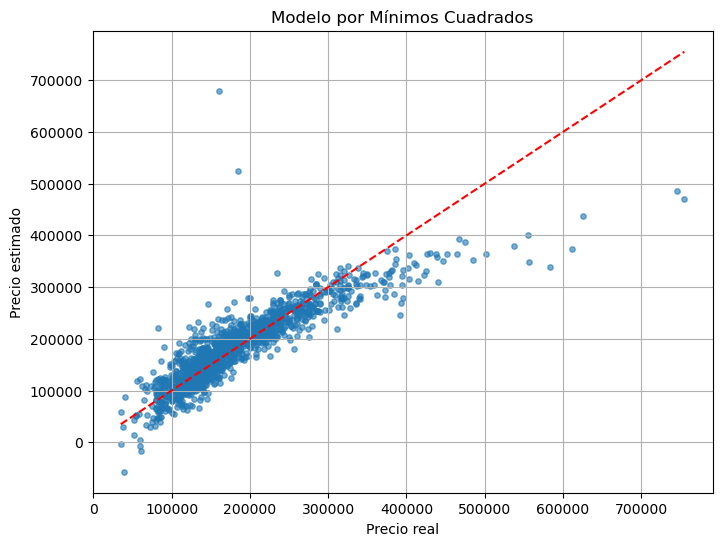

In [185]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y, y_pred, alpha=0.6, s=15)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Precio real")
plt.ylabel("Precio estimado")
plt.title("Modelo por Mínimos Cuadrados")
plt.grid(True)
plt.show()

In [186]:
# ============================================================
# SELECCIÓN DE UNA VIVIENDA ESPECÍFICA PARA EVALUACIÓN
# ============================================================

# Ingresar el ID de la vivienda que se desea analizar
id_vivienda = int(input("Ingrese el ID de la vivienda que desea analizar: "))

# Buscar la fila correspondiente a ese ID
fila_casa = df[df["Id"] == id_vivienda]

if fila_casa.empty:
    print("No se encontró una vivienda con ese ID.")
else:
    print("\nDatos de la vivienda seleccionada:")
    display(fila_casa)

    # Índice real dentro del dataset
    indice_real = fila_casa.index[0]

    # Precio real
    precio_real = y.iloc[indice_real]

    # Precio estimado por el modelo
    precio_estimado = precios_estimados[indice_real]

    # Error absoluto
    error_absoluto = abs(precio_real - precio_estimado)

    # Error porcentual
    error_porcentual = (error_absoluto / precio_real) * 100

    print("\nRESULTADOS DE LA PREDICCIÓN")
    print("----------------------------------")
    print(f"Precio real:      ${precio_real:,.2f}")
    print(f"Precio estimado:  ${precio_estimado:,.2f}")
    print(f"Error absoluto:   ${error_absoluto:,.2f}")
    print(f"Error porcentual: {error_porcentual:.2f}%")



Ingrese el ID de la vivienda que desea analizar:  1



Datos de la vivienda seleccionada:


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500



RESULTADOS DE LA PREDICCIÓN
----------------------------------
Precio real:      $208,500.00
Precio estimado:  $215,750.49
Error absoluto:   $7,250.49
Error porcentual: 3.48%


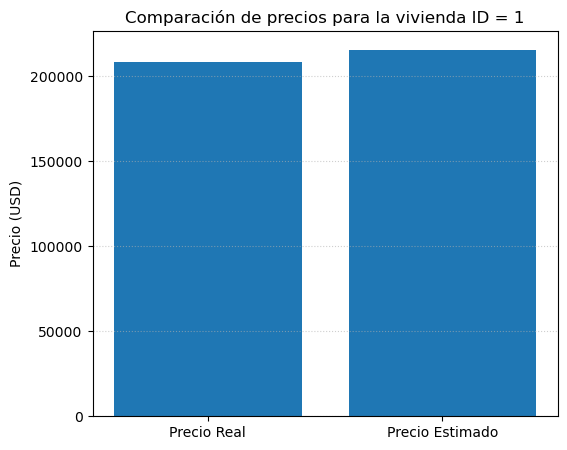

In [187]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA COMPARATIVA PARA LA VIVIENDA SELECCIONADA
# ============================================================

valores = [precio_real, precio_estimado]
etiquetas = ["Precio Real", "Precio Estimado"]

plt.figure(figsize=(6,5))
plt.bar(etiquetas, valores)
plt.title(f"Comparación de precios para la vivienda ID = {id_vivienda}")
plt.ylabel("Precio (USD)")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.show()


In [110]:
# ============================================================
# ANÁLISIS DE LA INFLUENCIA DE LAS VARIABLES EN EL MODELO
# ============================================================

# Nombres de las variables utilizadas en el modelo
nombres_variables = X_modelo.columns

# Los coeficientes obtenidos representan el peso de cada variable
coeficientes = coeficientes_modelo

# Se calcula el valor absoluto para medir la magnitud de influencia
influencia = np.abs(coeficientes)

# Se crea una tabla resumen para visualizar resultados
tabla_influencia = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes,
    "Influencia (|coeficiente|)": influencia
})

# Se ordena de mayor a menor influencia
tabla_influencia = tabla_influencia.sort_values(
    by="Influencia (|coeficiente|)",
    ascending=False
)

print("\nINFLUENCIA DE LAS VARIABLES EN EL PRECIO DE LA VIVIENDA")
print("--------------------------------------------------------")
display(tabla_influencia)



INFLUENCIA DE LAS VARIABLES EN EL PRECIO DE LA VIVIENDA
--------------------------------------------------------


,Variable,Coeficiente,Influencia (|coeficiente|)
1,OverallQual,24810.712608,24810.712608
8,GarageCars,16082.351816,16082.351816
7,FullBath,5536.209545,5536.209545
2,YearBuilt,-53.829519,53.829519
6,GrLivArea,38.571145,38.571145
3,BsmtFinSF1,21.779537,21.779537
4,TotalBsmtSF,13.821910,13.821910
9,GarageArea,6.926318,6.926318
5,1stFlrSF,6.413862,6.413862
0,LotArea,0.498042,0.498042


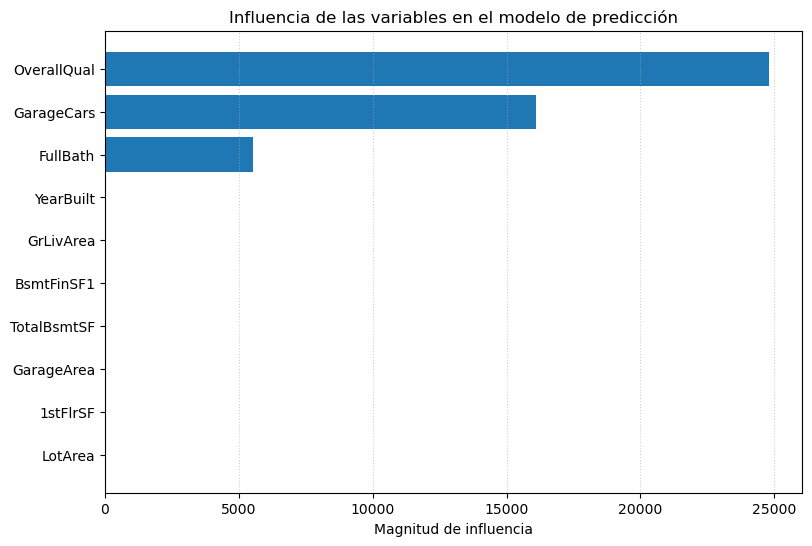

In [111]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA DE INFLUENCIA DE VARIABLES
# ============================================================

plt.figure(figsize=(9,6))

plt.barh(
    tabla_influencia["Variable"],
    tabla_influencia["Influencia (|coeficiente|)"]
)

plt.xlabel("Magnitud de influencia")
plt.title("Influencia de las variables en el modelo de predicción")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle=":", alpha=0.6)

plt.show()


In [189]:
# ============================================================
# TOP 10 MEJORES PREDICCIONES
# ============================================================

top_mejores = tabla_resultados.sort_values(
    by="Error_Absoluto"
).head(10)

print("\nTOP 10 MEJORES PREDICCIONES (MENOR ERROR)")
print("-----------------------------------------")
display(top_mejores)



TOP 10 MEJORES PREDICCIONES (MENOR ERROR)
-----------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
83,84,126500,126499.607491,0.392509,0.392509,0.000310
922,923,169990,170021.146484,-31.146484,31.146484,0.018323
741,742,142000,142041.161441,-41.161441,41.161441,0.028987
356,357,173000,172949.231821,50.768179,50.768179,0.029346
1203,1204,213000,213088.026225,-88.026225,88.026225,0.041327
994,995,337500,337399.389100,100.610900,100.610900,0.029811
924,925,207500,207618.480033,-118.480033,118.480033,0.057099
1206,1207,107000,107224.153036,-224.153036,224.153036,0.209489
1207,1208,200000,199726.409376,273.590624,273.590624,0.136795
1032,1033,310000,309683.755983,316.244017,316.244017,0.102014


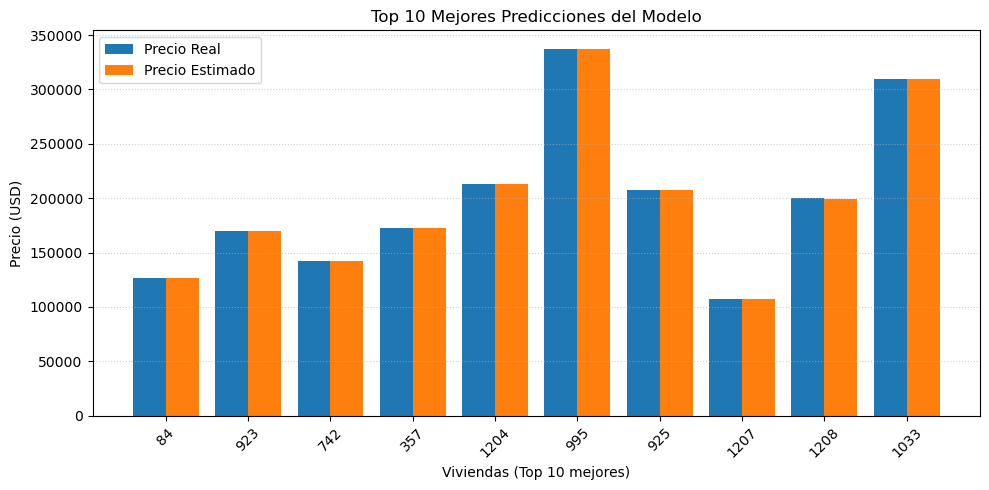

In [119]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# GRÁFICA TOP 10 MEJORES PREDICCIONES
# ============================================================

indices = np.arange(len(top_mejores))

plt.figure(figsize=(10,5))

plt.bar(indices - 0.2, top_mejores["Precio_Real"], width=0.4, label="Precio Real")
plt.bar(indices + 0.2, top_mejores["Precio_Estimado"], width=0.4, label="Precio Estimado")

plt.xlabel("Viviendas (Top 10 mejores)")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Mejores Predicciones del Modelo")

plt.xticks(indices, top_mejores["ID"], rotation=45)
plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


In [118]:
# ============================================================
# TOP 10 PEORES PREDICCIONES
# ============================================================

top_peores = tabla_resultados.sort_values(
    by="Error_Absoluto",
    ascending=False
).head(10)

print("\nTOP 10 PEORES PREDICCIONES (MAYOR ERROR)")
print("----------------------------------------")
display(top_peores)



TOP 10 PEORES PREDICCIONES (MAYOR ERROR)
----------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
1298,1299,160000,679982.319428,-519982.319428,519982.319428,324.988950
523,524,184750,524098.605985,-339348.605985,339348.605985,183.679895
691,692,755000,469733.295132,285266.704868,285266.704868,37.783670
1182,1183,745000,485806.569574,259193.430426,259193.430426,34.791064
803,804,582933,337982.168821,244950.831179,244950.831179,42.020409
898,899,611657,372789.403802,238867.596198,238867.596198,39.052540
1046,1047,556581,349338.508135,207242.491865,207242.491865,37.234920
1169,1170,625000,437498.268134,187501.731866,187501.731866,30.000277
769,770,538000,378953.316960,159046.683040,159046.683040,29.562580
440,441,555000,400980.116352,154019.883648,154019.883648,27.751330


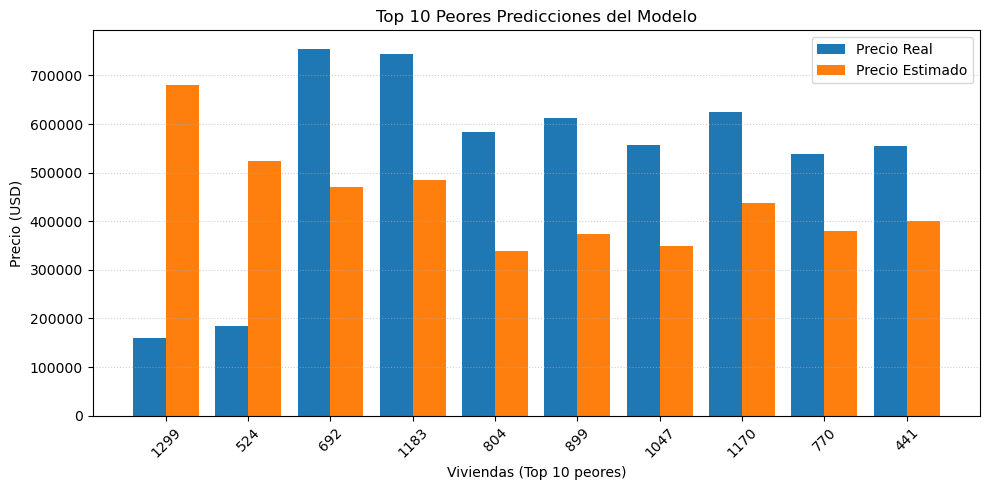

In [190]:
# ============================================================
# GRÁFICA TOP 10 PEORES PREDICCIONES
# ============================================================

indices = np.arange(len(top_peores))

plt.figure(figsize=(10,5))

plt.bar(indices - 0.2, top_peores["Precio_Real"], width=0.4, label="Precio Real")
plt.bar(indices + 0.2, top_peores["Precio_Estimado"], width=0.4, label="Precio Estimado")

plt.xlabel("Viviendas (Top 10 peores)")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Peores Predicciones del Modelo")

plt.xticks(indices, top_peores["ID"], rotation=45)
plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


In [207]:
import numpy as np

# ============================================
# RMSE — MODELO SIN NORMALIZAR
# ============================================

# Cálculo de residuos (error por vivienda)
residuos = y.values - y_pred

# Error Cuadrático Medio (MSE)
MSE = np.mean(residuos ** 2)

# Raíz del Error Cuadrático Medio (RMSE)
RMSE = np.sqrt(MSE)

print("\nEVALUACIÓN GLOBAL — MODELO SIN NORMALIZAR")
print("----------------------------------------")
print(f"MSE: {MSE:,.2f}")
print(f"RMSE: {RMSE:,.2f} USD")



EVALUACIÓN GLOBAL — MODELO SIN NORMALIZAR
----------------------------------------
MSE: 1,421,205,466.70
RMSE: 37,698.88 USD


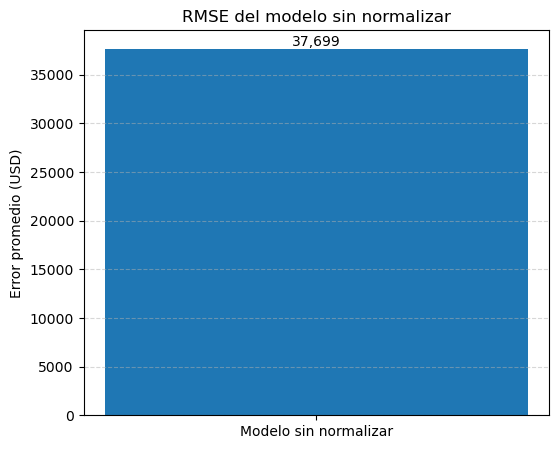

In [208]:
import matplotlib.pyplot as plt

# ============================================
# GRÁFICA DEL RMSE — MODELO SIN NORMALIZAR
# ============================================

plt.figure(figsize=(6, 5))

plt.bar(["Modelo sin normalizar"], [RMSE])

plt.ylabel("Error promedio (USD)")
plt.title("RMSE del modelo sin normalizar")

# Mostrar valor encima de la barra
plt.text(0, RMSE, f"{RMSE:,.0f}", ha='center', va='bottom')

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


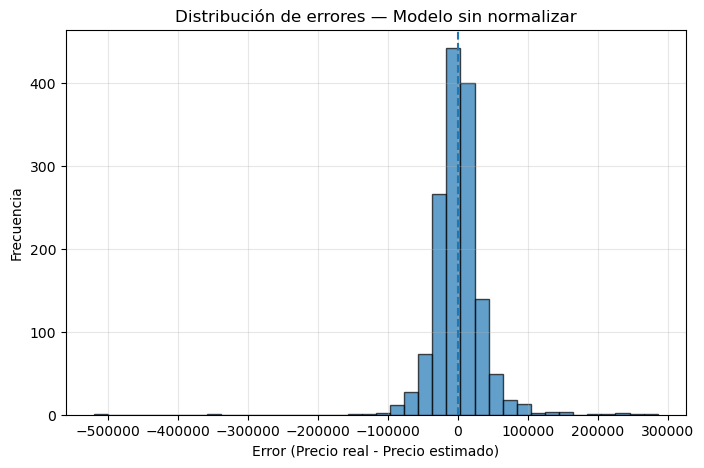

In [210]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# DISTRIBUCIÓN DE ERRORES — MODELO SIN NORMALIZAR
# ============================================

# Cálculo de residuos
errores = y.values - y_pred

plt.figure(figsize=(8, 5))

plt.hist(errores, bins=40, edgecolor='black', alpha=0.7)

# Línea vertical en cero (error ideal)
plt.axvline(0, linestyle='--')

plt.title("Distribución de errores — Modelo sin normalizar")
plt.xlabel("Error (Precio real - Precio estimado)")
plt.ylabel("Frecuencia")

plt.grid(alpha=0.3)
plt.show()


In [213]:
import pandas as pd
import numpy as np

# ============================================
# TABLA DE ERRORES POR VIVIENDA (SIN NORMALIZAR)
# ============================================

# Precio real
precio_real = y.values

# Precio estimado (modelo sin normalizar)
precio_estimado = y_pred

# Error (residuo)
error = precio_real - precio_estimado

# Error absoluto
error_abs = np.abs(error)

# Error porcentual
error_pct = (error_abs / precio_real) * 100

# Construcción de la tabla
tabla_errores_sin_norm = pd.DataFrame({
    "Id": df["Id"],
    "Precio_Real": precio_real,
    "Precio_Estimado": precio_estimado,
    "Error": error,
    "Error_Absoluto": error_abs,
    "Error_Porcentual (%)": error_pct
})

print("\nTABLA DE ERRORES POR VIVIENDA (MODELO SIN NORMALIZAR)")
print("-----------------------------------------------------")

display(tabla_errores_sin_norm.head())



TABLA DE ERRORES POR VIVIENDA (MODELO SIN NORMALIZAR)
-----------------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
0,1,208500,215750.493884,-7250.493884,7250.493884,3.477455
1,2,181500,189216.294906,-7716.294906,7716.294906,4.251402
2,3,223500,217103.247690,6396.752310,6396.752310,2.862082
3,4,140000,221121.843064,-81121.843064,81121.843064,57.944174
4,5,250000,285253.550739,-35253.550739,35253.550739,14.101420


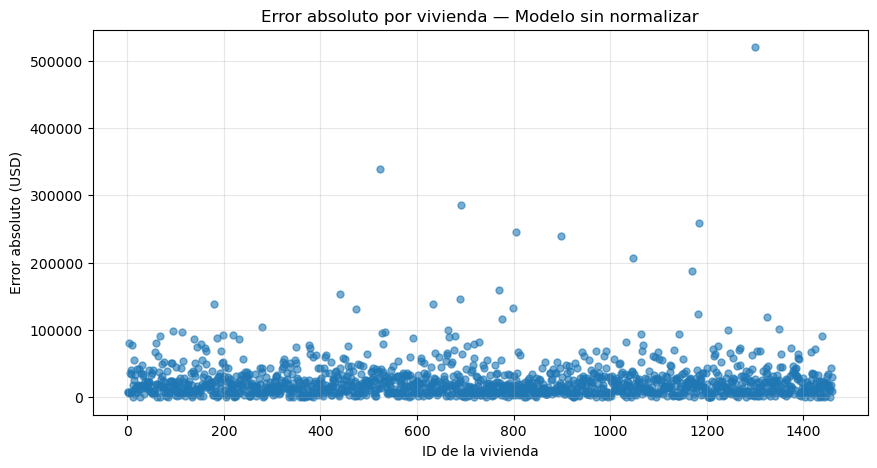

In [214]:
import matplotlib.pyplot as plt

# ============================================
# GRÁFICA: ERROR ABSOLUTO POR VIVIENDA
# MODELO SIN NORMALIZAR
# ============================================

plt.figure(figsize=(10, 5))

plt.scatter(
    tabla_errores_sin_norm["Id"],
    tabla_errores_sin_norm["Error_Absoluto"],
    alpha=0.6,
    s=25
)

plt.title("Error absoluto por vivienda — Modelo sin normalizar")
plt.xlabel("ID de la vivienda")
plt.ylabel("Error absoluto (USD)")

plt.grid(alpha=0.3)
plt.show()


**MODELO NORMALIZADO**

In [154]:
import pandas as pd

df = pd.read_csv("train.csv", sep=";")
df.head()


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500
1,2,9600,6,1976,978,1262,1262,1262,2,2,460,181500
2,3,11250,7,2001,486,920,920,1786,2,2,608,223500
3,4,9550,7,1915,216,756,961,1717,1,3,642,140000
4,5,14260,8,2000,655,1145,1145,2198,2,3,836,250000


In [155]:
# Variables explicativas
X = df.drop("SalePrice", axis=1)

# Variable objetivo
y = df["SalePrice"]


In [156]:
X = X.drop("Id", axis=1)

print("Columnas del modelo:")
print(X.columns.tolist())


Columnas del modelo:
['LotArea', 'OverallQual', 'YearBuilt', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'GarageCars', 'GarageArea']


In [157]:
import numpy as np

media_X = X.mean()
std_X = X.std()

X_norm = (X - media_X) / std_X

print("Primeras filas normalizadas:")
display(X_norm.head())


Primeras filas normalizadas:


,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea
0,-0.207071,0.651256,1.050634,0.575228,-0.459145,-0.793162,0.370207,0.789470,0.311618,0.350880
1,-0.091855,-0.071812,0.156680,1.171591,0.466305,0.257052,-0.482347,0.789470,0.311618,-0.060710
2,0.073455,0.651256,0.984415,0.092875,-0.313261,-0.627611,0.514836,0.789470,0.311618,0.631510
3,-0.096864,0.651256,-1.862993,-0.499103,-0.687089,-0.521555,0.383528,-1.025689,1.649742,0.790533
4,0.375020,1.374324,0.951306,0.463410,0.199611,-0.045596,1.298881,0.789470,1.649742,1.697903


In [158]:
n = X_norm.shape[0]

# Columna de unos (término independiente)
columna_unos = np.ones((n, 1))

# Matriz final del modelo
A_norm = np.hstack((columna_unos, X_norm.values))

# Vector y
b = y.values

print("Dimensión matriz A:", A_norm.shape)


Dimensión matriz A: (1460, 11)


In [159]:
AT = A_norm.T
ATA = AT @ A_norm
ATb = AT @ b

coeficientes_norm = np.linalg.solve(ATA, ATb)

print("Coeficientes del modelo:")
print(coeficientes_norm)


Coeficientes del modelo:
[180921.19589041   5489.89163307  30539.19917069   9205.37883809
   8489.61515631   4117.05601756   3884.08836123  24888.46720654
  -1040.50647208   9028.5153973    1318.78481358]


In [160]:
y_pred_norm = A_norm @ coeficientes_norm

print("Primeras 5 predicciones:")
print(y_pred_norm[:5])

print("\nPrimeros 5 valores reales:")
print(y.values[:5])


Primeras 5 predicciones:
[220925.75382087 182437.79372205 222974.57868018 200586.88094912
 286926.35740752]

Primeros 5 valores reales:
[208500 181500 223500 140000 250000]


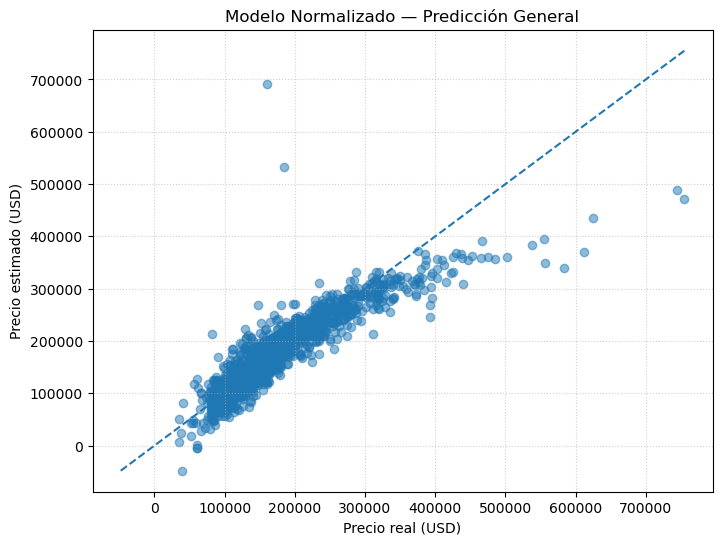

In [161]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y.values, y_pred_norm, alpha=0.5)

# Línea ideal y = x
min_price = min(y.values.min(), y_pred_norm.min())
max_price = max(y.values.max(), y_pred_norm.max())

plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")

plt.xlabel("Precio real (USD)")
plt.ylabel("Precio estimado (USD)")
plt.title("Modelo Normalizado — Predicción General")

plt.grid(True, linestyle=":", alpha=0.6)
plt.show()


In [ ]:
import numpy as np

# ============================================================
# PREDICCIÓN INDIVIDUAL (MODELO NORMALIZADO) — SIN GRÁFICA
# ============================================================

# Ingreso del ID
id_usuario = int(input("Ingrese el ID de la vivienda que desea analizar: "))

# Buscar vivienda
vivienda = df[df["Id"] == id_usuario]

if vivienda.empty:
    print(" ID no encontrado en el dataset")

else:
    print("\nDatos originales de la vivienda seleccionada:")
    display(vivienda)

    # Preparar datos
    X_vivienda = vivienda.drop(["SalePrice", "Id"], axis=1)

    # Normalización con parámetros del modelo
    X_vivienda_norm = (X_vivienda - media_X) / std_X

    # Convertir a vector NumPy
    fila = X_vivienda_norm.values

    # Agregar intercepto
    fila = np.hstack(([1], fila[0]))

    # Predicción
    precio_estimado = fila @ coeficientes_norm
    precio_real = vivienda["SalePrice"].values[0]

    # Cálculo de errores
    error_abs = abs(precio_real - precio_estimado)
    error_pct = (error_abs / precio_real) * 100

    # Mostrar resultados
    print("\nRESULTADOS DE LA PREDICCIÓN")
    print("-----------------------------")
    print(f"Precio real:      ${precio_real:,.2f}")
    print(f"Precio estimado:  ${precio_estimado:,.2f}")
    print(f"Error absoluto:   ${error_abs:,.2f}")
    print(f"Error porcentual: {error_pct:.2f}%")


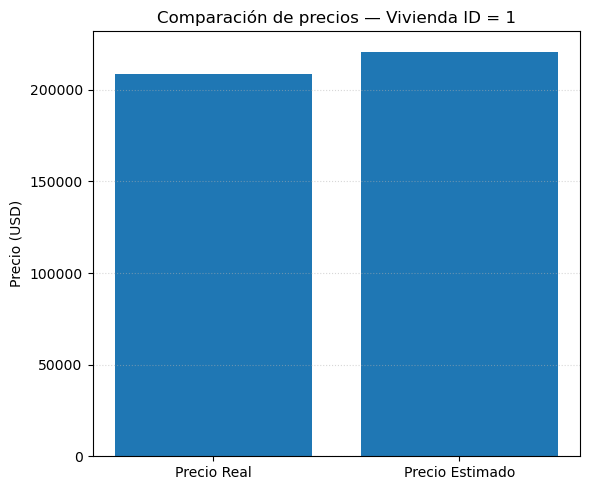

In [177]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA: PRECIO REAL VS PRECIO ESTIMADO (INDIVIDUAL)
# ============================================================

plt.figure(figsize=(6,5))

valores = [precio_real, precio_estimado]
etiquetas = ["Precio Real", "Precio Estimado"]

plt.bar(etiquetas, valores)

plt.ylabel("Precio (USD)")
plt.title(f"Comparación de precios — Vivienda ID = {id_usuario}")

plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


In [178]:
import pandas as pd
import numpy as np

# ============================================================
# ANÁLISIS DE LA INFLUENCIA DE LAS VARIABLES (MODELO NORMALIZADO)
# ============================================================

# Quitamos el intercepto (primer coeficiente)
coeficientes_variables = coeficientes_norm[1:]

# Nombres de las variables del modelo
nombres_variables = X.columns.tolist()

# Influencia absoluta (magnitud del coeficiente)
influencia = np.abs(coeficientes_variables)

# Crear tabla resumen
tabla_influencia = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes_variables,
    "Influencia (|coeficiente|)": influencia
})

# Ordenar de mayor a menor influencia
tabla_influencia = tabla_influencia.sort_values(
    by="Influencia (|coeficiente|)",
    ascending=False
)

print("\nINFLUENCIA DE LAS VARIABLES EN EL MODELO NORMALIZADO")
print("------------------------------------------------------")

display(tabla_influencia)



INFLUENCIA DE LAS VARIABLES EN EL MODELO NORMALIZADO
------------------------------------------------------


,Variable,Coeficiente,Influencia (|coeficiente|)
1,OverallQual,30539.199171,30539.199171
6,GrLivArea,24888.467207,24888.467207
2,YearBuilt,9205.378838,9205.378838
8,GarageCars,9028.515397,9028.515397
3,BsmtFinSF1,8489.615156,8489.615156
0,LotArea,5489.891633,5489.891633
4,TotalBsmtSF,4117.056018,4117.056018
5,1stFlrSF,3884.088361,3884.088361
9,GarageArea,1318.784814,1318.784814
7,FullBath,-1040.506472,1040.506472


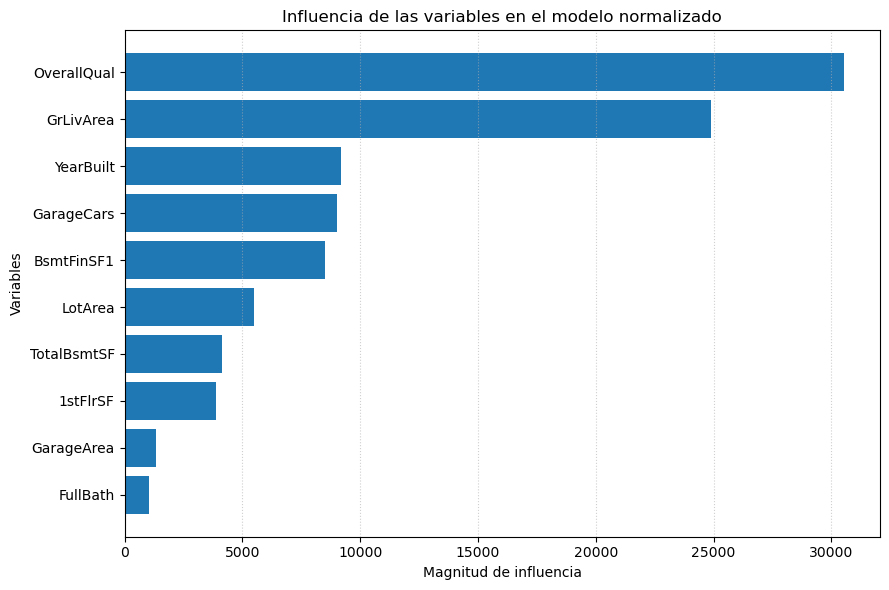

In [179]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA DE INFLUENCIA DE VARIABLES
# ============================================================

plt.figure(figsize=(9,6))

plt.barh(
    tabla_influencia["Variable"],
    tabla_influencia["Influencia (|coeficiente|)"]
)

plt.xlabel("Magnitud de influencia")
plt.ylabel("Variables")
plt.title("Influencia de las variables en el modelo normalizado")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


In [191]:
# ============================================================
# TOP 10 PEORES PREDICCIONES (MAYOR ERROR ABSOLUTO)
# ============================================================

top_peores = tabla_errores.sort_values(
    by="Error_Absoluto",
    ascending=False
).head(10)

print("\nTOP 10 PEORES PREDICCIONES (MODELO NORMALIZADO)")
print("------------------------------------------------")

display(top_peores)



TOP 10 PEORES PREDICCIONES (MODELO NORMALIZADO)
------------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
1298,1299,160000,690546.501948,-530546.501948,530546.501948,331.591564
523,524,184750,531808.523175,-347058.523175,347058.523175,187.853057
691,692,755000,471797.486362,283202.513638,283202.513638,37.510267
1182,1183,745000,487765.553754,257234.446246,257234.446246,34.528114
803,804,582933,339297.879499,243635.120501,243635.120501,41.794704
898,899,611657,370680.092583,240976.907417,240976.907417,39.397392
1046,1047,556581,349358.531958,207222.468042,207222.468042,37.231323
1169,1170,625000,434890.542662,190109.457338,190109.457338,30.417513
440,441,555000,394441.056617,160558.943383,160558.943383,28.929539
769,770,538000,383147.332499,154852.667501,154852.667501,28.783024


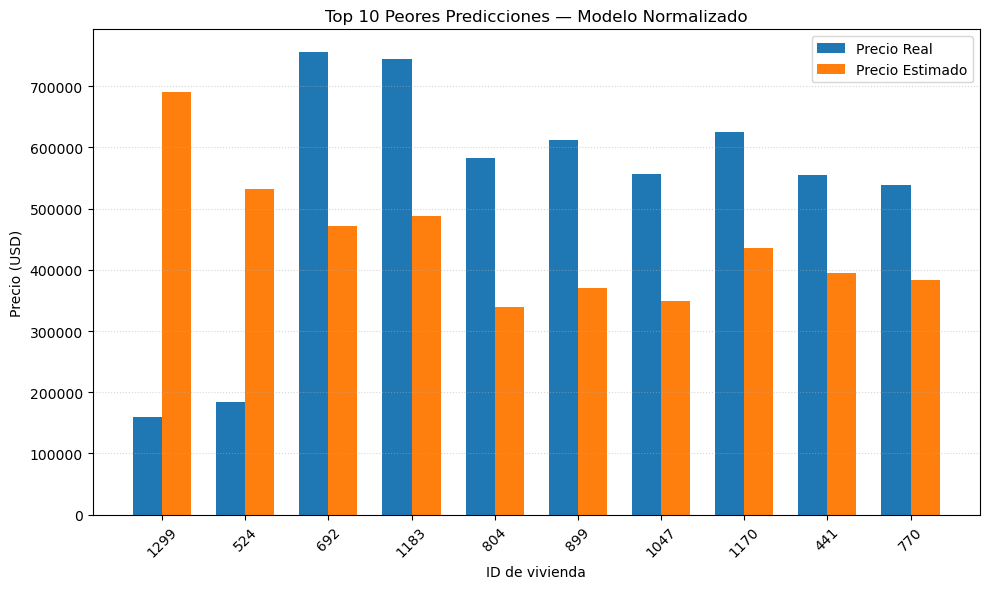

In [192]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# GRÁFICA: TOP 10 PEORES PREDICCIONES
# ============================================================

ids = top_peores["Id"].astype(str)
precio_real = top_peores["Precio_Real"]
precio_estimado = top_peores["Precio_Estimado"]

x = np.arange(len(ids))
ancho = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - ancho/2, precio_real, ancho, label="Precio Real")
plt.bar(x + ancho/2, precio_estimado, ancho, label="Precio Estimado")

plt.xticks(x, ids, rotation=45)
plt.xlabel("ID de vivienda")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Peores Predicciones — Modelo Normalizado")

plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


In [193]:
# ============================================================
# TOP 10 MEJORES PREDICCIONES (MENOR ERROR ABSOLUTO)
# ============================================================

top_mejores = tabla_errores.sort_values(
    by="Error_Absoluto",
    ascending=True
).head(10)

print("\nTOP 10 MEJORES PREDICCIONES (MODELO NORMALIZADO)")
print("------------------------------------------------")

display(top_mejores)



TOP 10 MEJORES PREDICCIONES (MODELO NORMALIZADO)
------------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
1401,1402,193000,193019.993435,-19.993435,19.993435,0.010359
1051,1052,200141,200113.790020,27.209980,27.209980,0.013595
433,434,181000,181046.548238,-46.548238,46.548238,0.025717
1410,1411,230000,230078.875549,-78.875549,78.875549,0.034294
650,651,205950,206034.822818,-84.822818,84.822818,0.041186
254,255,145000,145119.431719,-119.431719,119.431719,0.082367
1232,1233,101800,101923.457617,-123.457617,123.457617,0.121275
386,387,81000,80839.232090,160.767910,160.767910,0.198479
1117,1118,130000,129812.152533,187.847467,187.847467,0.144498
475,476,132500,132696.288408,-196.288408,196.288408,0.148142


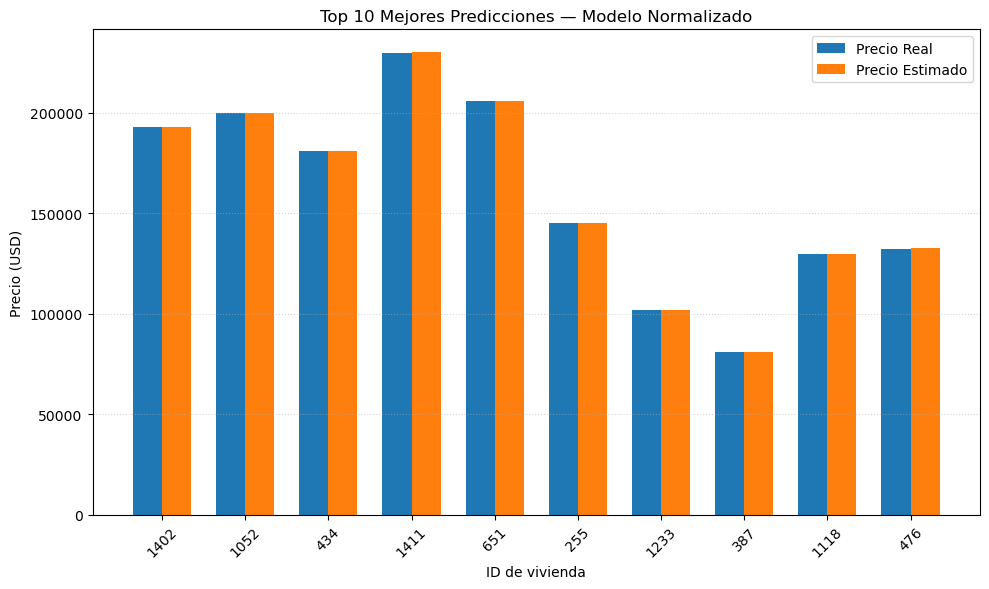

In [194]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# GRÁFICA: TOP 10 MEJORES PREDICCIONES
# ============================================================

ids = top_mejores["Id"].astype(str)
precio_real = top_mejores["Precio_Real"]
precio_estimado = top_mejores["Precio_Estimado"]

x = np.arange(len(ids))
ancho = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - ancho/2, precio_real, ancho, label="Precio Real")
plt.bar(x + ancho/2, precio_estimado, ancho, label="Precio Estimado")

plt.xticks(x, ids, rotation=45)
plt.xlabel("ID de vivienda")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Mejores Predicciones — Modelo Normalizado")

plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


In [205]:
import numpy as np

# ============================================================
# RMSE — MODELO NORMALIZADO
# ============================================================

# Cálculo de residuos
residuos_norm = y.values - y_pred_norm

# Error cuadrático medio (MSE)
MSE_norm = np.mean(residuos_norm ** 2)

# Raíz del error cuadrático medio (RMSE)
RMSE_norm = np.sqrt(MSE_norm)

print("\nEVALUACIÓN GLOBAL — MODELO NORMALIZADO")
print("---------------------------------------")
print(f"MSE:  {MSE_norm:,.2f}")
print(f"RMSE: {RMSE_norm:,.2f} USD")



EVALUACIÓN GLOBAL — MODELO NORMALIZADO
---------------------------------------
MSE:  1,366,063,846.28
RMSE: 36,960.30 USD


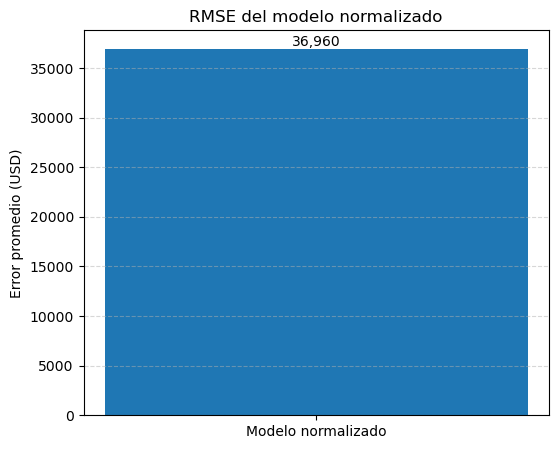

In [209]:
import matplotlib.pyplot as plt

# ============================================
# GRÁFICA DEL RMSE — MODELO NORMALIZADO
# ============================================

plt.figure(figsize=(6, 5))

plt.bar(["Modelo normalizado"], [RMSE_norm])

plt.ylabel("Error promedio (USD)")
plt.title("RMSE del modelo normalizado")

# Mostrar valor encima de la barra
plt.text(0, RMSE_norm, f"{RMSE_norm:,.0f}", 
         ha='center', va='bottom')

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


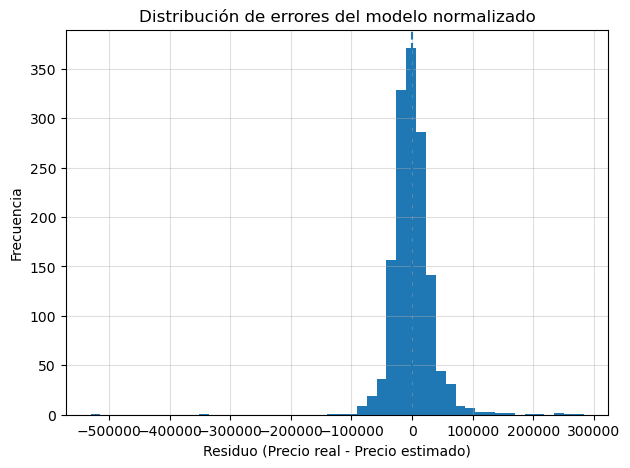

In [202]:
plt.figure(figsize=(7,5))

plt.hist(residuos_norm, bins=50)

plt.axvline(0, linestyle='--')

plt.xlabel("Residuo (Precio real - Precio estimado)")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores del modelo normalizado")

plt.grid(True, alpha=0.4)

plt.show()


In [211]:
import pandas as pd
import numpy as np

# ============================================
# TABLA DE ERRORES POR VIVIENDA (MODELO NORMALIZADO)
# ============================================

# Precio real
precio_real = y.values

# Precio estimado
precio_estimado = y_pred_norm

# Error (residuo)
error = precio_real - precio_estimado

# Error absoluto
error_abs = np.abs(error)

# Error porcentual
error_pct = (error_abs / precio_real) * 100

# Construcción de la tabla
tabla_errores = pd.DataFrame({
    "Id": df["Id"],
    "Precio_Real": precio_real,
    "Precio_Estimado": precio_estimado,
    "Error": error,
    "Error_Absoluto": error_abs,
    "Error_Porcentual (%)": error_pct
})

print("\nTABLA DE ERRORES POR VIVIENDA (MODELO NORMALIZADO)")
print("---------------------------------------------------")

display(tabla_errores.head())



TABLA DE ERRORES POR VIVIENDA (MODELO NORMALIZADO)
---------------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
0,1,208500,220925.753821,-12425.753821,12425.753821,5.959594
1,2,181500,182437.793722,-937.793722,937.793722,0.516691
2,3,223500,222974.578680,525.421320,525.421320,0.235088
3,4,140000,200586.880949,-60586.880949,60586.880949,43.276344
4,5,250000,286926.357408,-36926.357408,36926.357408,14.770543


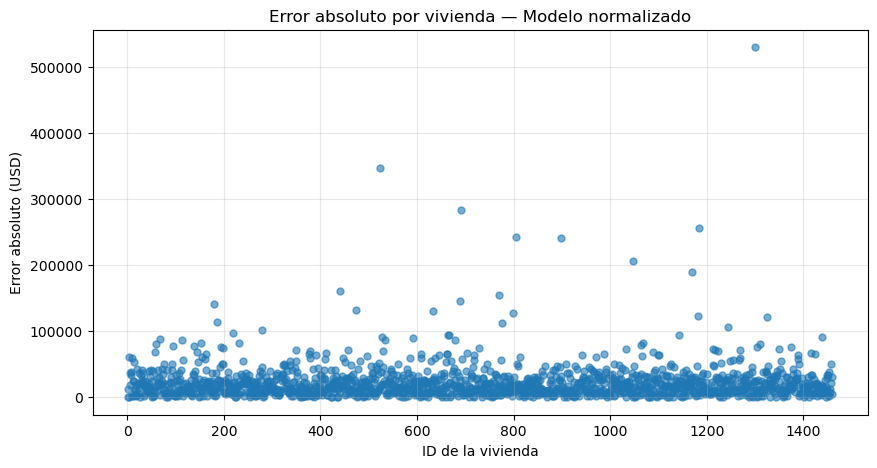

In [212]:
import matplotlib.pyplot as plt

# ============================================
# GRÁFICA: ERROR ABSOLUTO POR VIVIENDA
# ============================================

plt.figure(figsize=(10, 5))

plt.scatter(
    tabla_errores["Id"],
    tabla_errores["Error_Absoluto"],
    alpha=0.6,
    s=25
)

plt.title("Error absoluto por vivienda — Modelo normalizado")
plt.xlabel("ID de la vivienda")
plt.ylabel("Error absoluto (USD)")

plt.grid(alpha=0.3)
plt.show()
